## Delay Prediction Modeling

### Objective
This notebook builds a classification model to predict whether a procurement request will be delayed.

The purpose is not to replace bottleneck analysis, but to complement it by identifying risky requests early.

This modeling step supports:
- proactive intervention
- delay risk screening
- operational decision support

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from pathlib import Path
import pandas as pd

# .parent moves up from 'notebooks' to 'Project - Procurement Bottleneck'
BASE_DIR = Path.cwd().parent 
FINAL_DIR = BASE_DIR / "data" / "final"

# Now it will look in 'd:\Data Analysis\Project - Procurement Bottleneck\data\final\'
df = pd.read_csv(FINAL_DIR / "final_request_level.csv")

print(df.shape)
df.head()

(5000, 22)


,Request_ID,Request_Start,Request_End,Total_Processing,Total_Waiting,SLA_Hours,Request_Type,Priority,Department_Requesting,Vendor_Type,...,System_Load,Num_Stages,Total_TAT,Delay_Ratio,SLA_Breach_Hours,Delayed_Flag,Is_High_Value_Request,Is_High_Complexity,Bottleneck_Stage,Max_Stage_Delay
0,R00001,2025-06-29 15:04:12,2025-07-10 09:00:00,172.34,40.88,191.4,IT Purchase,Low,Operations,Internal,...,0.950714,9,257.93,1.347597,66.53,1,0,0,Finance Approval,58.42
1,R00002,2025-01-08 11:30:00,2025-01-12 09:00:00,48.96,10.62,140.4,IT Purchase,High,Admin,Internal,...,0.034389,4,93.50,0.665954,0.00,0,0,0,Procurement Review,25.54
2,R00003,2025-07-07 10:52:48,2025-07-12 17:58:12,98.21,14.60,217.8,Equipment,Low,IT,Internal,...,0.542696,4,127.09,0.583517,0.00,0,0,0,Finance Approval,51.92
3,R00004,2025-07-12 14:00:36,2025-07-18 09:00:00,89.70,17.95,145.2,Office Supplies,Low,Admin,Internal,...,0.382927,4,138.99,0.957231,0.00,0,0,0,Procurement Review,40.89
4,R00005,2025-03-12 11:22:12,2025-03-17 15:14:24,86.16,22.06,102.6,Office Supplies,High,Admin,External,...,0.289751,7,123.87,1.207310,21.27,1,0,0,Finance Approval,24.26


### Target Variable

The target variable is `Delayed_Flag`, which indicates whether total turnaround time exceeded SLA.

- `0` = not delayed
- `1` = delayed

In [5]:
df["Delayed_Flag"].value_counts()

Delayed_Flag
0    3424
1    1576
Name: count, dtype: int64

In [7]:
(df["Delayed_Flag"].value_counts(normalize=True) * 100).round(2)

Delayed_Flag
0    68.48
1    31.52
Name: proportion, dtype: float64

### Leakage Warning

Two variables were intentionally excluded from the model:

- `Delay_Ratio`
- `SLA_Breach_Hours`

These were removed because they are directly derived from turnaround time and SLA, which are also used to define `Delayed_Flag`.

Keeping them would create target leakage and produce misleadingly perfect results.

In [9]:
features = [
    "Priority",
    "Request_Type",
    "Department_Requesting",
    "Vendor_Type",
    "Request_Amount",
    "Complexity_Score",
    "System_Load",
    "Num_Stages",
    "Total_Processing",
    "Total_Waiting",
    "Max_Stage_Delay",
    "Is_High_Value_Request",
    "Is_High_Complexity",
]

target = "Delayed_Flag"

X = df[features].copy()
y = df[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 13)
Target shape: (5000,)


### Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 13)
Test shape: (1000, 13)


### Preprocessing and Model Setup

In [11]:
categorical = [
    "Priority",
    "Request_Type",
    "Department_Requesting",
    "Vendor_Type",
]

numerical = [col for col in features if col not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numerical,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=5,
            ),
        ),
    ]
)

### Model Training

In [12]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Evaluation

In [13]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm

array([[655,  30],
       [ 16, 299]])

In [14]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       685
           1       0.91      0.95      0.93       315

    accuracy                           0.95      1000
   macro avg       0.94      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



### Interpretation of Results

The model is evaluated using:
- confusion matrix
- precision
- recall
- F1-score

A useful model should not be perfect.  
Some errors are expected in realistic workflow prediction.

In this project, the model is especially valuable if it can identify delayed requests with high recall, since missing risky cases is more costly than raising a small number of false alarms.

### Feature Importance

In [15]:
import numpy as np

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances,
    }
).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
17,num__Num_Stages,0.284345
18,num__Total_Processing,0.220521
19,num__Total_Waiting,0.218848
15,num__Complexity_Score,0.054659
20,num__Max_Stage_Delay,0.051229
5,cat__Request_Type_Office Supplies,0.047446
22,num__Is_High_Complexity,0.022419
14,num__Request_Amount,0.018563
6,cat__Request_Type_Vendor Contract,0.014207
16,num__System_Load,0.011252


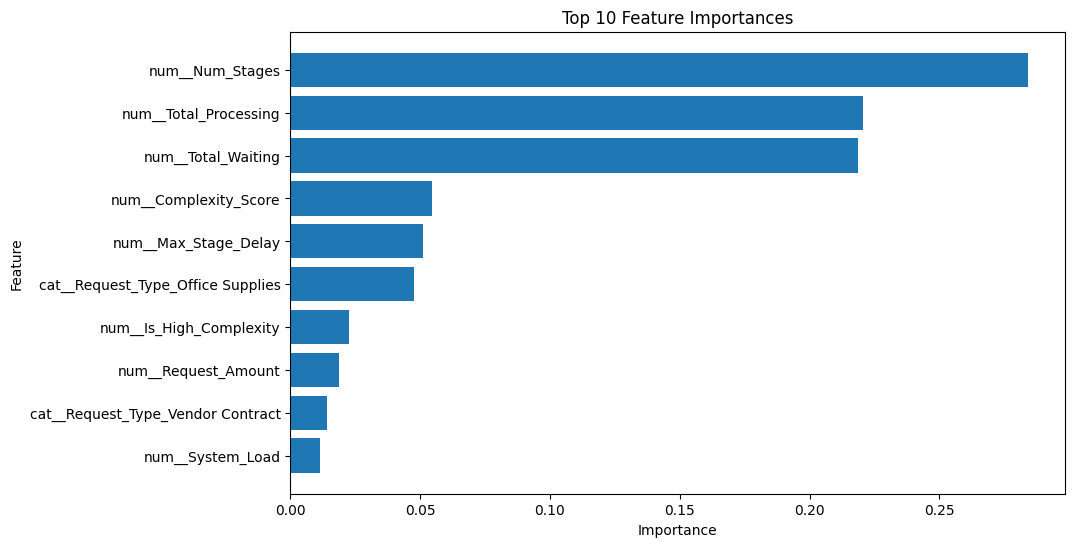

In [16]:
import matplotlib.pyplot as plt

top_importance = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Key Modeling Insights

- The model predicts delay risk with strong overall performance  
- Leakage features were removed to ensure the evaluation remained realistic  
- Delay prediction is driven by a combination of request characteristics and process-related variables  
- The model is suitable as a decision-support tool, not as a replacement for process diagnosis  

## Conclusion

This notebook showed that procurement delays can be predicted using structured request and workflow features.

The model adds value by identifying likely delay cases early, while the bottleneck analysis explains where the delays actually originate.

Together, these components make the project both analytically strong and operationally relevant.